<a href="https://colab.research.google.com/github/sakthivelk-gl/learn/blob/main/Austo_Auto_Campaign_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Austo Automobiles - Campaign Analytics**

# **Problem Statement**

## Context

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

## Objective

They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.


## Data Description

The data contains detailed snapshot of Austo automobile companies customer base and their demographics and financial status to their car purchasing choices.

*   List item
*   List item




# **Title**

## Sub Title1

Sub Title1


## Sub Title 2

Sub Title 2


## Sub Title 3

Sub Title 3




# **Data Overview**

## Import Python Libraries

In [1]:
# Libraries for Data Reading and Data Manipulation
import numpy as np
import pandas as pd

# Libraries for Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Data

In [2]:
# Mount the google colab drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load data file
# Make sure the file name has no spaces in the end and correct a correct file path
file_path = '/content/drive/MyDrive/GLProject1/austo_automobile.csv'

# Load the csv data from the specified file path
data = pd.read_csv(file_path)

# Create a copy of the data to keep the original data for reference
df = data.copy()

## Check the structure of the data

In [4]:
# To print first 5 rows from the csv file
print(df.head())

# To show number of rows, number of columns
print(f"\nData Shape: \n {df.shape}")

   Age  Gender Profession Marital_status      Education  No_of_Dependents  \
0   53    Male   Business        Married  Post Graduate                 4   
1   53   Femal   Salaried        Married  Post Graduate                 4   
2   53  Female   Salaried        Married  Post Graduate                 3   
3   53  Female   Salaried        Married       Graduate                 2   
4   53    Male   Salaried        Married  Post Graduate                 3   

  Personal_loan House_loan Partner_working  Salary  Partner_salary  \
0            No         No             Yes   99300         70700.0   
1           Yes         No             Yes   95500         70300.0   
2            No         No             Yes   97300         60700.0   
3           Yes         No             Yes   72500         70300.0   
4            No         No             Yes   79700         60200.0   

   Total_salary  Price Make  
0        170000  61000  SUV  
1        165800  61000  SUV  
2        158000  57000  SU

- This dataset has 1581 rows and 14 Columns

## Check the types of the data

In [5]:
# Lists the data types for each column in the data frame
print('\nDtypes:\n', df.dtypes)

# Provides a full summary
print('\nInfo:\n')
df.info()



Dtypes:
 Age                   int64
Gender               object
Profession           object
Marital_status       object
Education            object
No_of_Dependents      int64
Personal_loan        object
House_loan           object
Partner_working      object
Salary                int64
Partner_salary      float64
Total_salary          int64
Price                 int64
Make                 object
dtype: object

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 

## Check for missing values

In [6]:
# Check for missing values for all the columns
print('\nMissing Values: \n', df.isnull().sum())


Missing Values: 
 Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64


- Gender Column has 53 missing values. Fix Required.
- Partner Salary has 106 missing values likely non-working partners. No Action needed.

## Check the Statistical Summary

In [7]:
# Display the statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


- Add infrances of the above data set
- xx
- xx

## Check for data irregularities and Fix



In [8]:
# Check for unique values
print(f"Unique raw values   : {df['Gender'].unique()}")

Unique raw values   : ['Male' 'Femal' 'Female' nan 'Femle']


 - There are 2 fixes required to correct the dataset.
 - a. Fill with the missing values in Gender Column
 - b. Correct the spelling of 'Femal' & 'Femle' with '' Female.

In [9]:
# Missing value count & percentage
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
dtype_map     = df.dtypes.astype(str)

missing_df = pd.DataFrame({
    'Column'       : missing_count.index,
    'Data Type'    : dtype_map.values,
    'Missing Count': missing_count.values,
    'Missing %'    : missing_pct.values
})
missing_df = missing_df.sort_values('Missing Count', ascending=False).reset_index(drop=True)

print("\nMissing Value Summary :\n")
print(missing_df.to_string(index=False))


Missing Value Summary :

          Column Data Type  Missing Count  Missing %
  Partner_salary   float64            106       6.70
          Gender    object             53       3.35
      Profession    object              0       0.00
  Marital_status    object              0       0.00
       Education    object              0       0.00
             Age     int64              0       0.00
No_of_Dependents     int64              0       0.00
   Personal_loan    object              0       0.00
 Partner_working    object              0       0.00
      House_loan    object              0       0.00
          Salary     int64              0       0.00
    Total_salary     int64              0       0.00
           Price     int64              0       0.00
            Make    object              0       0.00


In [10]:
# Duplicate rows check
dup_count = df.duplicated().sum()
print(f"\n Duplicate rows : {dup_count} \n")


 Duplicate rows : 0 



In [11]:
# Gender Fix : Step 1 - Correct the Spelling (Typos)
df['Gender'] = df['Gender'].replace({'Femal': 'Female', 'Femle': 'Female'})

# After fixing the Typos.
print(df['Gender'].value_counts(dropna=False).to_string())


Gender
Male      1199
Female     329
NaN         53


- Out of 1528 non-null rows: Male = 1199 (78.47%) and Female = 329 (21.53%). The column is heavily dominated by One category (Male)
- Only 53 rows = 3.35% of the dataset. Such a small portion of data even an imperfect strategy causes minimal damage to the analysis.


In [12]:
# Male and Female % before Imputation

known = df['Gender'].dropna()   # only rows where Gender is present

total_known  = len(known)
male_count   = (known == 'Male').sum()
female_count = (known == 'Female').sum()
nan_count = (known == 'NaN').sum()
male_pct     = round(male_count   / total_known * 100, 2)
female_pct   = round(female_count / total_known * 100, 2)
nan_pct   = round(nan_count / total_known * 100, 2)

print(f"\nTotal non-null rows : {total_known}")
print(f"  Male             : {male_count}  ({male_pct}%)")
print(f"  Female           : {female_count}  ({female_pct}%)")
print(f"  NaN              : {nan_count}  ({nan_pct}%)")




Total non-null rows : 1528
  Male             : 1199  (78.47%)
  Female           : 329  (21.53%)
  NaN              : 0  (0.0%)


In [13]:
# # Gender Fix : Step 2 - Impute nulls with mode
# Mode is the safest choice for a binary categorical column.
# 'Male' is the dominant category (78.47%), so imputing with mode
#  minimises misleading to the overall distribution.

gender_mode = df['Gender'].mode()[0]
print(f"\nMode (most frequent value) : '{gender_mode}'")
print(f"Nulls to be filled         : {df['Gender'].isnull().sum()}")

df['Gender'] = df['Gender'].fillna(gender_mode)

# After Imputation
print(df['Gender'].value_counts(dropna=False).to_string())


Mode (most frequent value) : 'Male'
Nulls to be filled         : 53
Gender
Male      1252
Female     329


In [14]:
# Male and Female % After Imputation

known = df['Gender'].dropna()   # only rows where Gender is present

total_known  = len(known)
male_count   = (known == 'Male').sum()
female_count = (known == 'Female').sum()
male_pct     = round(male_count   / total_known * 100, 2)
female_pct   = round(female_count / total_known * 100, 2)

print(f"\nTotal non-null rows : {total_known}")
print(f"  Male             : {male_count}  ({male_pct}%)")
print(f"  Female           : {female_count}  ({female_pct}%)")


Total non-null rows : 1581
  Male             : 1252  (79.19%)
  Female           : 329  (20.81%)


## Observations and Insights

- A .CSV Data has been loaded into dataframe and perform the analysis.
- Given the data, 2 columns are having the data quality that need fix.
- Out of 1528 non-null rows: Male = 1199 (78.47%) and Female = 329 (21.53%). The column is heavily dominated by one category. Hence, the missing value to be updated by the Mode
- The data changes after impute is < 1%, hence the choice of mode used.

# **Univariate Analysis**

## Explore all the variables (categorical and numerical) in the data

In [15]:
summary_dtypes = df.dtypes.value_counts()

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('\nNumeric columns:', num_cols)
print('Total numeric:', len(num_cols))
print('\nCategorical columns:', cat_cols)
print('Total categorical:', len(cat_cols))


Numeric columns: ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
Total numeric: 6

Categorical columns: ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make']
Total categorical: 8


- From the above, there are 6 Numeric Columns in the Data set ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
- There are 8 Categorical Variables in the Data set ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make']

## Univariate Analysis - Numerical Variables

###
1. Age
2. No_of_Dependents
3. Salary
4. Partner_salary
5. Total_salary
6. Price

### 1. Univariate Analysis - Age

count    1581.000000
mean       31.922201
std         8.425978
min        22.000000
25%        25.000000
50%        29.000000
75%        38.000000
max        54.000000
Name: Age, dtype: float64


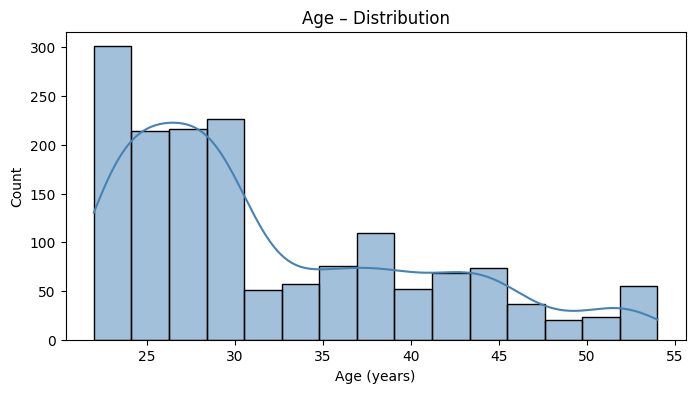

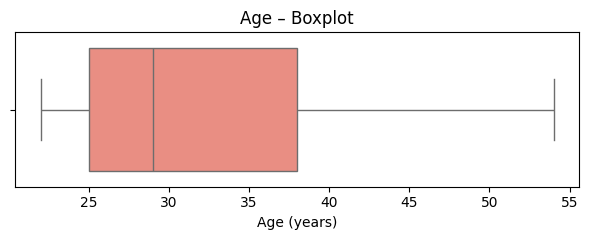

In [16]:
col = "Age"
print(df[col].describe())

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(df[col],kde=True, color="steelblue")
plt.title("Age – Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Age – Boxplot")
plt.xlabel("Age (years)")
plt.tight_layout()
plt.show()

- Most of our customers are young adults. [ Mean - 31 ]
- People in their 20s and 30s are the main buyers of Austo cars
- The boxplot confirms that most ages lie in a young age group and verlky few customers at the higher age (above 40 years).
- Overall, Austo’s marketing should primarily focus on young working professionals.

### 2. Univariate Analysis - No_of_Dependents

count    1581.000000
mean        2.457938
std         0.943483
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: No_of_Dependents, dtype: float64


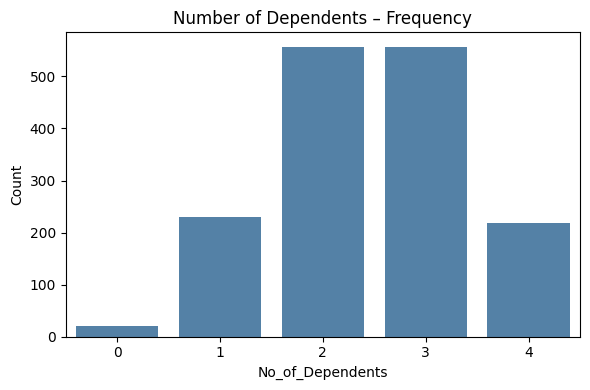

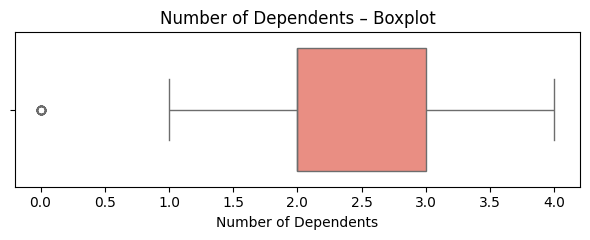

In [17]:
col = "No_of_Dependents"
print(df[col].describe())

# Countplot
plt.figure(figsize=(6, 4))
sns.countplot(x=df[col], color="steelblue")
plt.title("Number of Dependents – Frequency")
plt.xlabel("No_of_Dependents")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Number of Dependents – Boxplot")
plt.xlabel("Number of Dependents")
plt.tight_layout()
plt.show()

- Most customers have 2 or 3 dependents.
- The countplot shows that these two categories have the highest bars, while 0,1 and 4 dependent is less common. This means many buyers are family people who support children or parents.
- The boxplot shows that the number of dependents is mostly between 2 and 3.
- So, Austo’s typical customer is a family person and focus should be with family‑oriented features and marketing strategies like safety, space, comfort.


### 3. Univariate Analysis - Salary

count     1581.000000
mean     60392.220114
std      14674.825044
min      30000.000000
25%      51900.000000
50%      59500.000000
75%      71800.000000
max      99300.000000
Name: Salary, dtype: float64


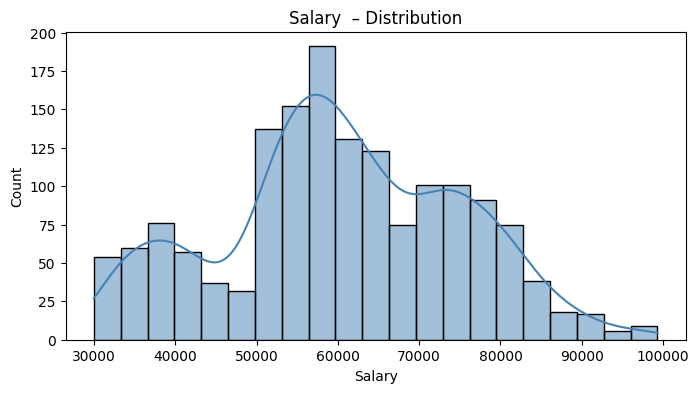

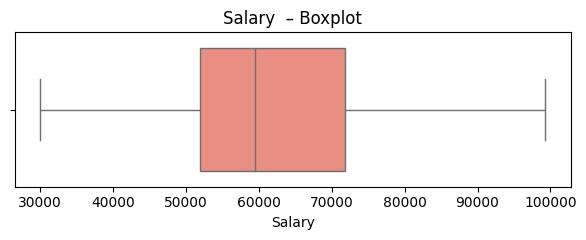

In [18]:
col = "Salary"
print(df[col].describe())

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(df[col],kde=True, color="steelblue")
plt.title("Salary  – Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Salary  – Boxplot")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()

- The salary distribution shows that most customers are from middle‑range income.
- The tallest bars fall between about 50k-75k dollars with an average salary of around 60,000$.
- This suggests that Austo’s cars are mostly bought by mid‑income customers, not by very low‑income or extremely high‑income groups.
- The boxplot shows a compact central area and a few higher values, indicating a small number of high income group but no extreme outliers.


### 4. Univariate Analysis - Partner_salary

count     1475.000000
mean     20225.559322
std      19573.149277
min          0.000000
25%          0.000000
50%      25600.000000
75%      38300.000000
max      80500.000000
Name: Partner_salary, dtype: float64


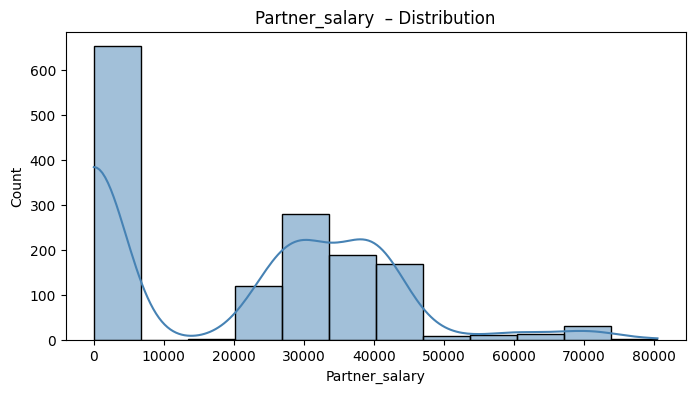

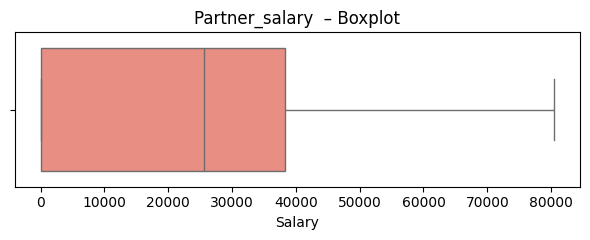

In [19]:
col = "Partner_salary"
print(df[col].describe())

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(df[col],kde=True, color="steelblue")
plt.title("Partner_salary  – Distribution")
plt.xlabel("Partner_salary")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Partner_salary  – Boxplot")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()

- The partner salary plot shows that many customers either have lower earning partners or no partner income at all.
- In the histogram, we see a peak at zero or near zero, representing customers whose partners do not work or whose income is not available.
- customers with higher partner salary (double income) can be targeted for higher‑priced top models, while single‑income families may be more price‑sensitive

### 5. Univariate Analysys - Total_salary

count      1581.000000
mean      79625.996205
std       25545.857768
min       30000.000000
25%       60500.000000
50%       78000.000000
75%       95900.000000
max      171000.000000
Name: Total_salary, dtype: float64


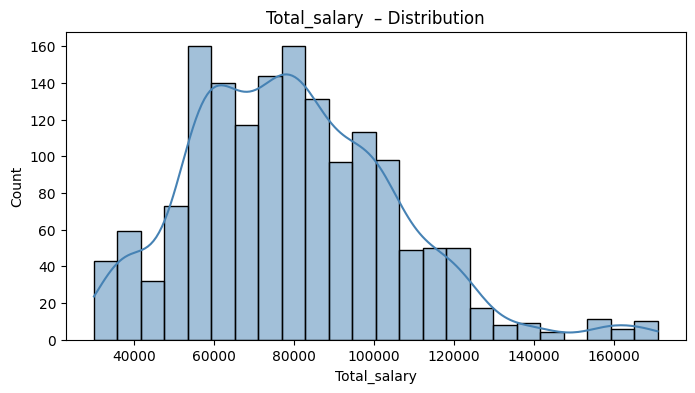

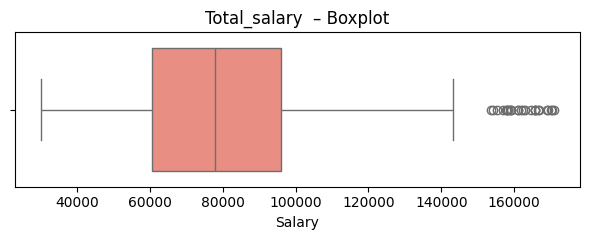

In [20]:
col = "Total_salary"
print(df[col].describe())

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(df[col],kde=True, color="steelblue")
plt.title("Total_salary  – Distribution")
plt.xlabel("Total_salary")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Total_salary  – Boxplot")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()

- The total salary combines the income of the customer and their partner.
- The distribution shows that most customers fall into a  middle‑income band, with total salary typically between about 60-100 K dollars.
- The shape of the curve says a slight right skew: a smaller group of high‑earning households with much higher total salary exists but is not the majority.
- The boxplot reporesents customers with very strong buying power, who are potential targets for SUVs or top versions.
- Overall, total salary is a stronger indicator of spending power than individual salary alone.

### 6. Univariate Analysys - Price

count     1581.000000
mean     35597.722960
std      13633.636545
min      18000.000000
25%      25000.000000
50%      31000.000000
75%      47000.000000
max      70000.000000
Name: Price, dtype: float64


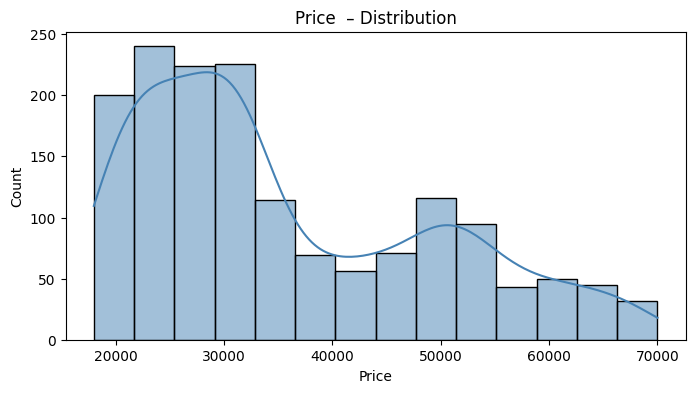

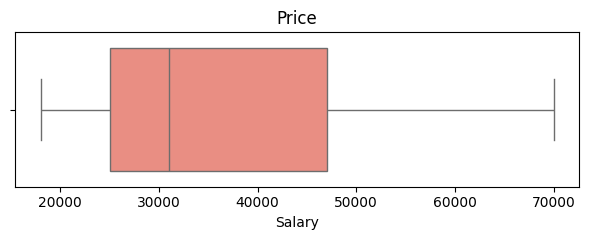

In [21]:
col = "Price"
print(df[col].describe())

# Histogram + KDE
plt.figure(figsize=(8, 4))
sns.histplot(df[col],kde=True, color="steelblue")
plt.title("Price  – Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.5))
sns.boxplot(x=df[col], color="salmon")
plt.title("Price")
plt.xlabel("Salary")
plt.tight_layout()
plt.show()

- The price distribution shows that most cars sold fall into a mid‑price range.
- We see that Austo’s customers are mostly in the mid‑income range, and they tend to buy cars in a moderate price band.



## Univariate Analysis - Categorical Variables

###
1. Gender
2. Profession
3. Marital_status
4. Education
5. Personal_loan
6. House_loan
7. Partner_working Make


==== Gender – value counts ====
Gender
Male      1252
Female     329
Name: count, dtype: int64


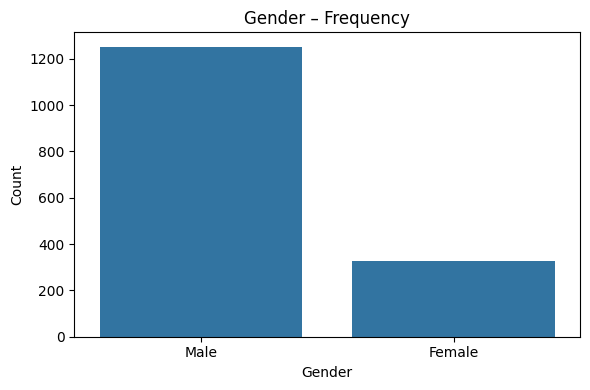


==== Profession – value counts ====
Profession
Salaried    896
Business    685
Name: count, dtype: int64


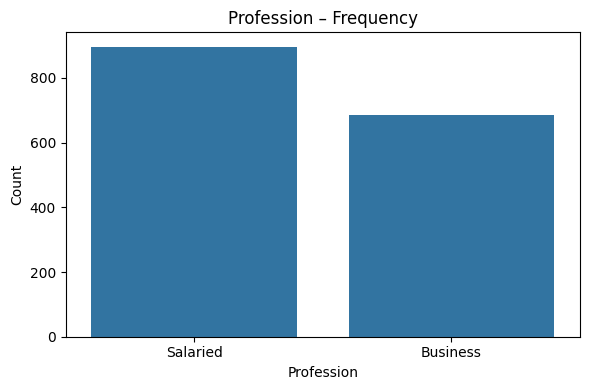


==== Marital_status – value counts ====
Marital_status
Married    1443
Single      138
Name: count, dtype: int64


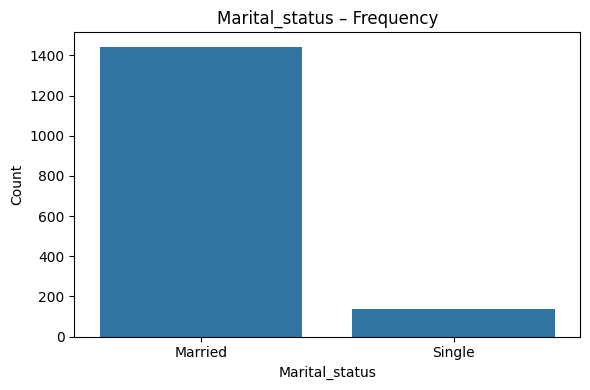


==== Education – value counts ====
Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64


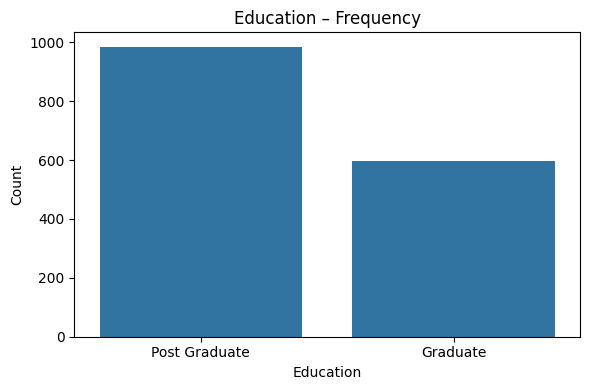


==== Personal_loan – value counts ====
Personal_loan
Yes    792
No     789
Name: count, dtype: int64


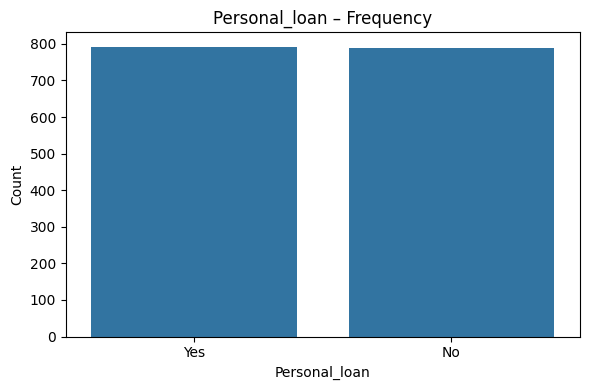


==== House_loan – value counts ====
House_loan
No     1054
Yes     527
Name: count, dtype: int64


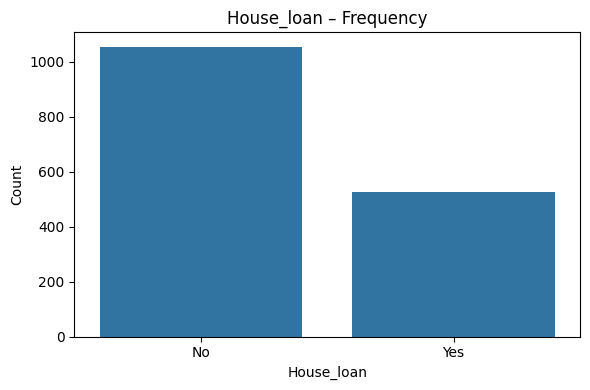


==== Partner_working – value counts ====
Partner_working
Yes    868
No     713
Name: count, dtype: int64


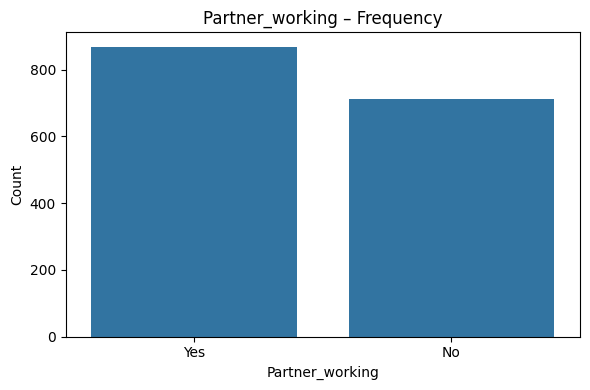


==== Make – value counts ====
Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64


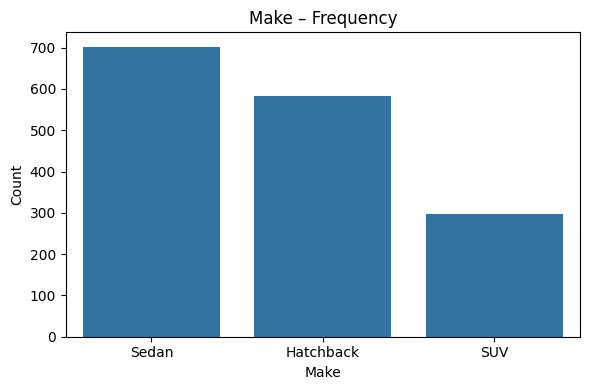

In [22]:
## Single code for all the Categorical Variables
cat_cols = ["Gender", "Profession", "Marital_status", "Education",
            "Personal_loan", "House_loan", "Partner_working", "Make"]

#cat_cols = ["Gender", "Profession"]
##           "Marital_status", "Education", "Personal_loan", "House_loan", "Partner_working", "Make"]

for col in cat_cols:
    print(f"\n==== {col} – value counts ====")
    print(df[col].value_counts(dropna=False))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"{col} – Frequency")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Observations and Insights - Univariate Analysis - Categorical Variables

### 1. Gender
- Most of Austo’s customers are Male.
- From the counts, we have about 1252 male customers and 329 female customers after fixing missing and spelling errors in the data.
- For marketing, Austo can continue to target male customers strongly, but there is also an opportunity to design campaigns specifically to attract more female buyers.





### 2. Profession
- There are two main profession groups in the data: Salaried and Business.
- The frequency table shows 896 Salaried customers and 685 Business customers.
  This tells us that salaried employees form a slightly larger share of Austo’s customers, but business owners also represent a significant portion.
- Austo should design separate product messages: stable income, EMI focused
  offers for Salaried customers, and flexible, status oriented offers for Business customers.


### 3. Marital_status

- The data shows that most customers are Married.There are 1443 Married customers and only 138 Single customers.
- This means Austo mainly attracts family oriented buyers rather than single individuals.


### 4. Education

- The customers are split between Graduate and Post Graduate. The counts show 985 Post Graduates and 596 Graduates. So, more than half of the customers have a higher education level.
- This suggests that Austo’s buyers are relatively well educated, and they may respond well to data driven communication.



### 5. Personal Loan

- The Yes and No for personal loans are almost evenly split.We have 792 customers with a personal loan and 789 customers without one.
- This indicates that having an existing personal loan does not strongly prevent people from buying a car.
- Austo can promote car loans and exchange offers even to customers who already have a personal loan, as many of them are still active buyers.




### 6. Housing Loan

- For house loans, more customers do not have a house loan. The data shows 1,054 customers without a house loan and 527 with a house loan.
- This suggests that many customers may still be in the stage of building assets (like a house and a car) and may have more flexibility in their monthly budgets.



### 7. Partner Working

- The partner’s employment status is almost balanced, with a slight tilt towards partners working.
- There are 868 customers whose partner is working and 713 whose partner is not working.
- This means that a large part of the customer base lives in dual income households, which generally have higher total salary and greater purchasing power.
- Austo can target premium variants to dual income families, while offering budget friendly options to single income households.





### 8. Make

- The Sedan is the most popular car type, followed by Hatchback, and then SUV.
- From the counts, we have 702 Sedans, 582 Hatchbacks, and 297 SUVs .
- This clearly shows that Sedans are the main volume driver for Austo, while Hatchbacks also contribute strongly, and SUVs form a smaller, more premium segment.






# **Bivariate Analysis**

In [23]:
# Collecting Numerical and Categorical Variables
num_cols = ["Age", "No_of_Dependents", "Salary", "Partner_salary", "Total_salary", "Price"]
cat_cols = ["Gender", "Profession", "Marital_status", "Education",
            "Personal_loan", "House_loan", "Partner_working", "Make"]

###  1. Relationship between all numerical variables

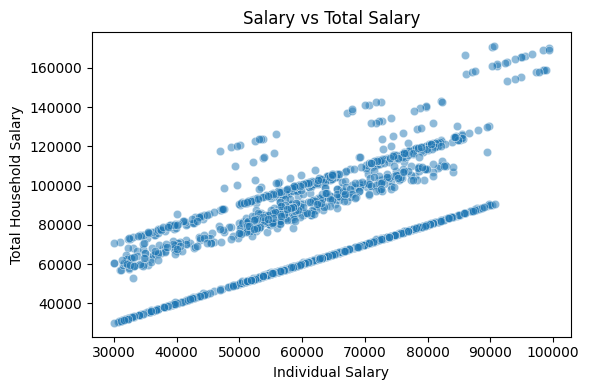

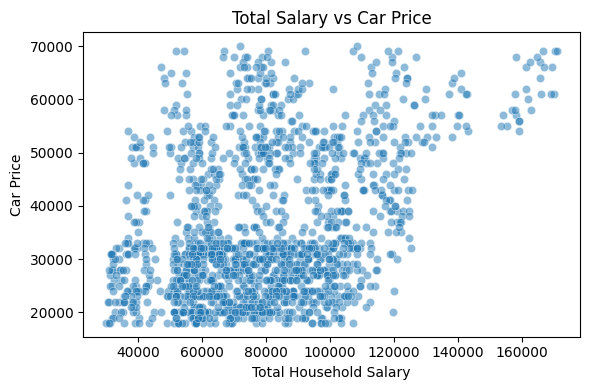

In [25]:
# Scatterplot : Pairwise relationships between numerical variables
# Salary vs Total_salary
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Salary", y="Total_salary", alpha=0.5)
plt.title("Salary vs Total Salary")
plt.xlabel("Individual Salary")
plt.ylabel("Total Household Salary")
plt.tight_layout()
plt.show()

# Total_salary vs Price
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Total_salary", y="Price", alpha=0.5)
plt.title("Total Salary vs Car Price")
plt.xlabel("Total Household Salary")
plt.ylabel("Car Price")
plt.tight_layout()
plt.show()

- In the Salary vs Total_salary plot, the points form an upward trend: as individual salary increases, total family income also increases.
- This confirms that higher earning customers usually belong to higher income customers, which is important when deciding which models to offer them.

- In the Total_salary vs Price plot, we see that more expensive cars are mostly bought by customers eholds with higher total salary.
- This suggests that SUVs and higher priced Sedans are more attractive to high income families, while lower priced cars suit mid income households.



###  2. Coreleation between all numerical variables

Correlation matrix:
                       Age  No_of_Dependents    Salary  Partner_salary  \
Age               1.000000         -0.189614  0.616899        0.126267   
No_of_Dependents -0.189614          1.000000 -0.031746        0.131253   
Salary            0.616899         -0.031746  1.000000        0.071049   
Partner_salary    0.126267          0.131253  0.071049        1.000000   
Total_salary      0.458869          0.092890  0.641560        0.813945   
Price             0.797831         -0.135839  0.409920        0.167725   

                  Total_salary     Price  
Age                   0.458869  0.797831  
No_of_Dependents      0.092890 -0.135839  
Salary                0.641560  0.409920  
Partner_salary        0.813945  0.167725  
Total_salary          1.000000  0.367823  
Price                 0.367823  1.000000  


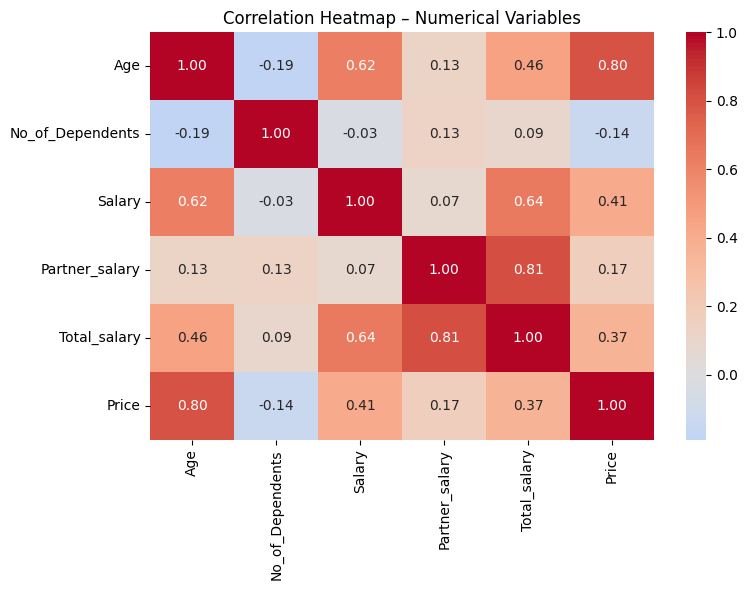

In [29]:
# Correlation matrix for numerical variables
corr = df[num_cols].corr()

print("Correlation matrix:")
print(corr)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap – Numerical Variables")
plt.tight_layout()
plt.show()

- Salary vs Total_salary has a strong positive correlation (close to +1).
This means that when individual salary increases, total household salary almost always increases as well.
- Total_salary vs Price shows a moderate positive correlation.
This tells us that higher total income is associated with higher car prices, so income is an important driver of what type of car customers buy.
- Age vs Salary / Total_salary shows a mild positive correlation.
This suggests that older customers tend to earn slightly more and therefore can afford slightly higher priced cars, but the relationship is not extremely strong.
- No_of_Dependents generally has weak correlations with salary and price, meaning family size alone does not strongly drive how much people spend.


### 3. Relationship between categorical vs numerical variables

### 3.1 Make  vs Price, Salary, Total_salary

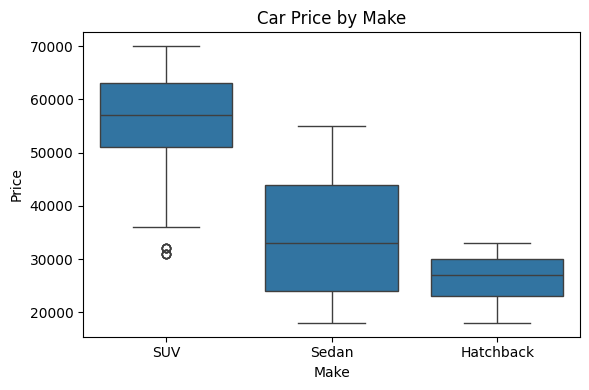

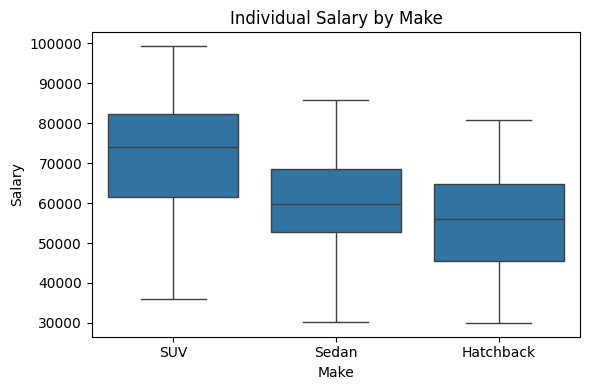

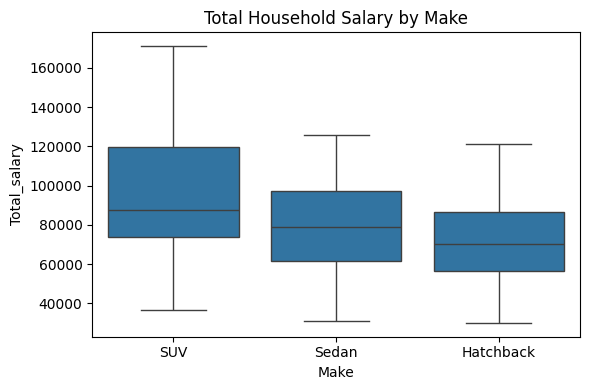

In [30]:
# Boxplot: Price by Make
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Make", y="Price")
plt.title("Car Price by Make")
plt.xlabel("Make")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Boxplot: Salary by Make
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Make", y="Salary")
plt.title("Individual Salary by Make")
plt.xlabel("Make")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

# Boxplot: Total_salary by Make
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Make", y="Total_salary")
plt.title("Total Household Salary by Make")
plt.xlabel("Make")
plt.ylabel("Total_salary")
plt.tight_layout()
plt.show()

- From the Price by Make boxplot, we see that SUVs generally have the highest prices, followed by Sedans, and then Hatchbacks as the most affordable. This means SUV is the premium segment, while Sedan and Hatchback serve the mid price and entry segments.
- The Salary and Total_salary by Make plots show that customers who buy SUVs tend to have higher individual and household incomes compared to those who buy Hatchbacks.
- Sedans sit in the middle: they are purchased by a wide range of income levels but still skew towards mid to higher incomes.
- For the business, this confirms that SUVs should be marketed to higher income, possibly dual income families, while Sedans and Hatchbacks can be promoted for mid income customers.


### 3.2 - Gender vs Price and Total_salary

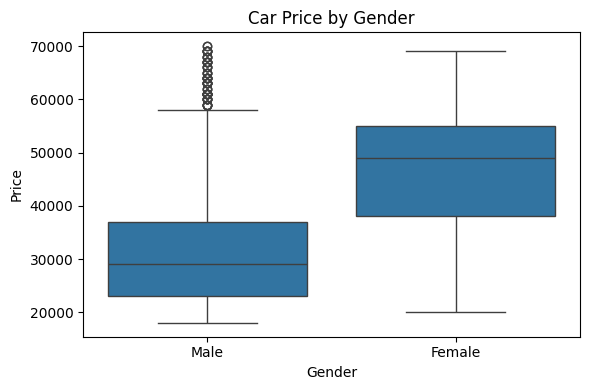

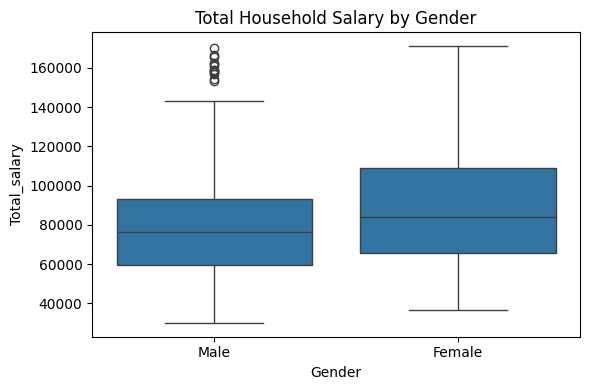

In [31]:
# Boxplot: Price by Gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Gender", y="Price")
plt.title("Car Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Boxplot: Total_salary by Gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Gender", y="Total_salary")
plt.title("Total Household Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Total_salary")
plt.tight_layout()
plt.show()

- The Car Price by Gender plot shows that both male and female customers buy cars in a similar overall price range
- Given that males are the majority of buyers, the spread for males is wider, indicating more variation in what men purchase, from lower priced to higher priced cars.
- spending power is broadly similar between male and female led customers.

# **Key Questions**